# 模型选择 + 欠拟合、过拟合

## 模型选择

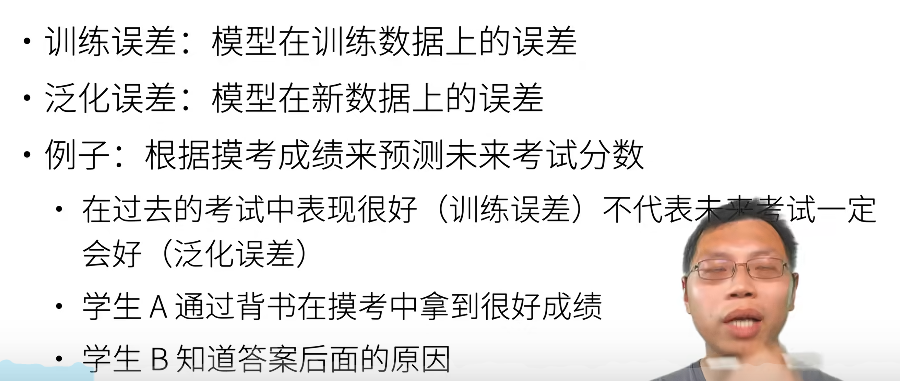

影响模型泛化的因素：
1. 可调整参数的数量。当可调整参数的数量（有时称为⾃由度）很⼤时，模型往往更容易过拟合。
2. 参数采⽤的值。当权重的取值范围较⼤时，模型可能更容易过拟合。
3. 训练样本的数量。即使你的模型很简单，也很容易过拟合只包含⼀两个样本的数据集。过拟合⼀个有数百万个样本的数据集则需要⼀个极其灵活的模型。

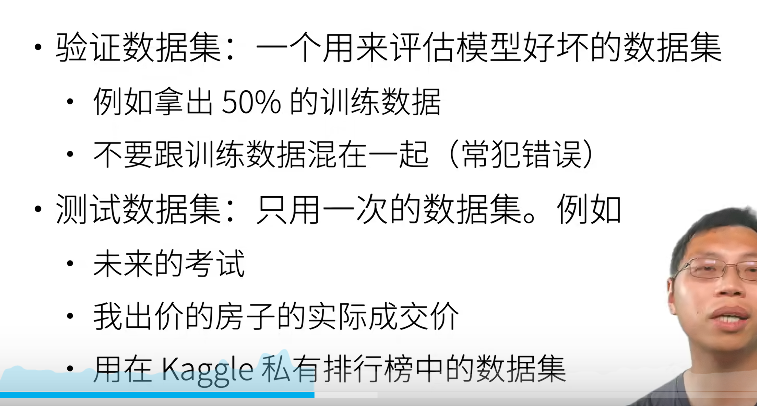

训练集：训练模型参数  
验证集：用于评估不同超参数下的模型性能，以选择最佳超参数集   
测试集：仅使用一次   
验证数据集不能和训练数据集混合

**K折交叉验证**  
当训练数据稀缺时，我们甚⾄可能⽆法提供⾜够的数据来构成⼀个合适的验证集。采⽤K折交叉验证：  
1. 原始训练数据被分成K个不重叠的⼦集。
2. 执⾏K次模型训练和验证，每次在K-1 个⼦集上进⾏训练，并在剩余的⼀个⼦集（在该轮中没有⽤于训练的⼦集）上进⾏验证。  
3. 通过对K次实验的结果取平均来估计训练和验证误差。

## 过、欠拟合

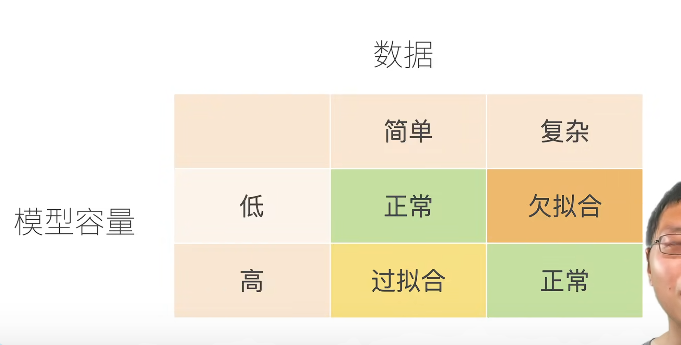

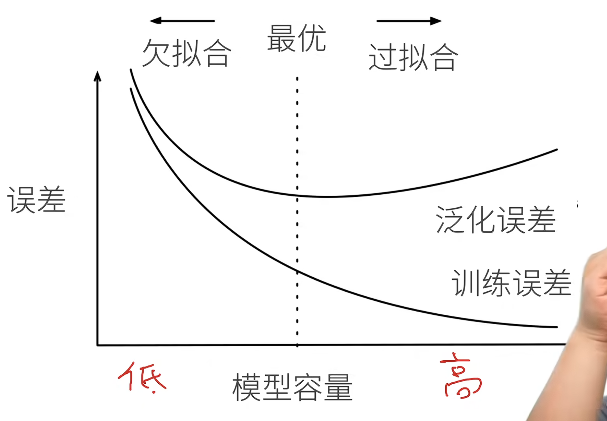

模型容量低：训练误差和泛化误差都高，欠拟合  
模型容量高：训练误差低，泛化误差高，过拟合

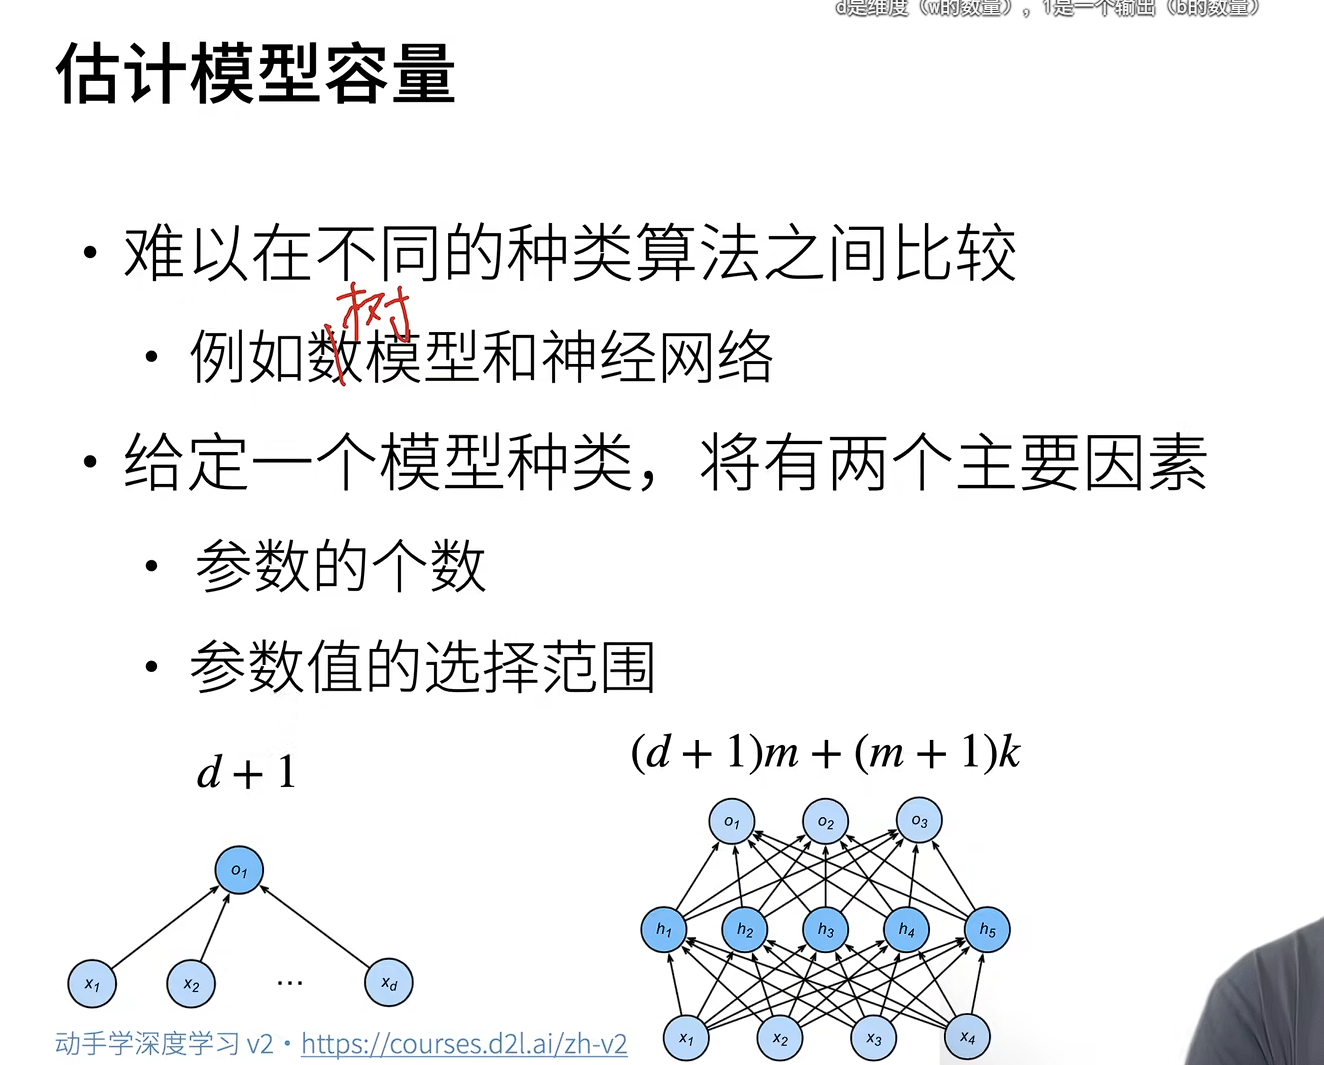

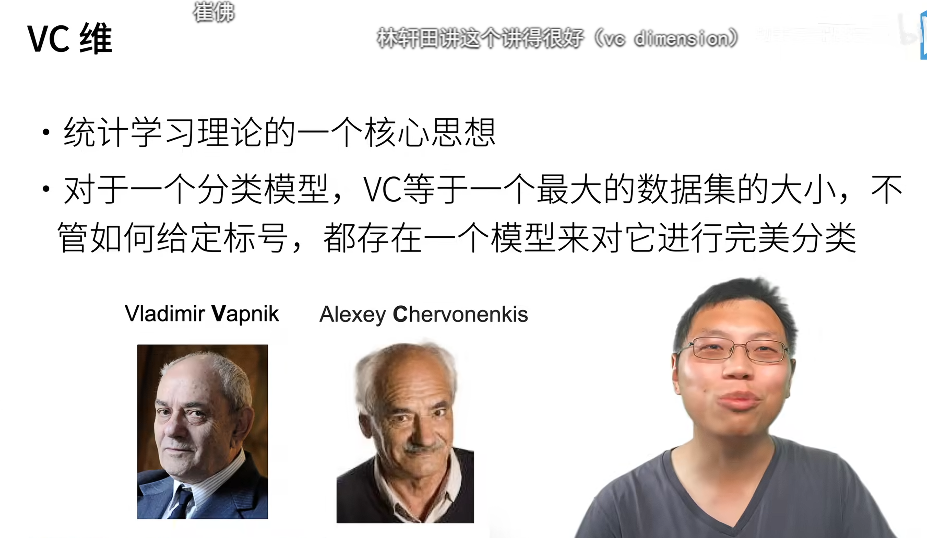
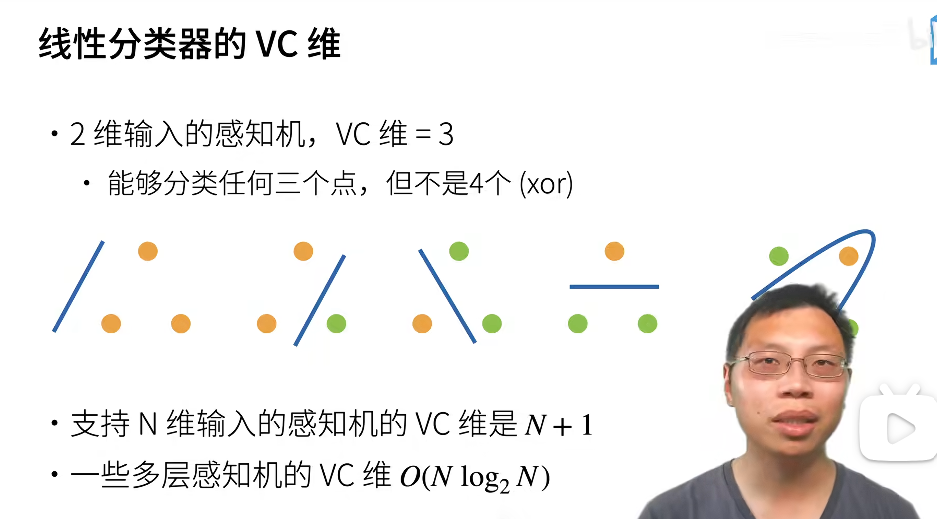
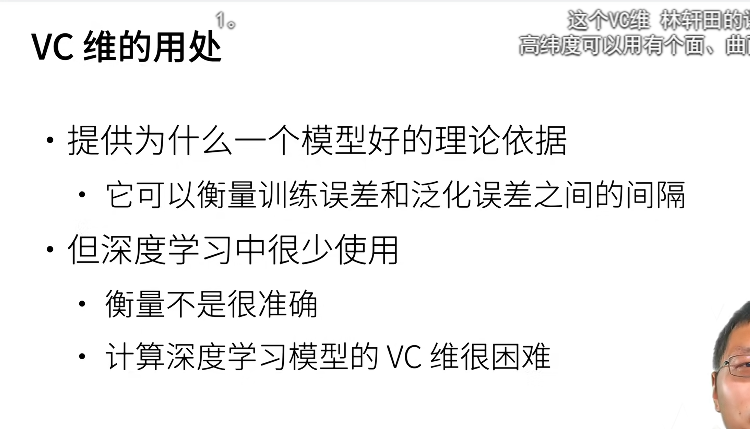

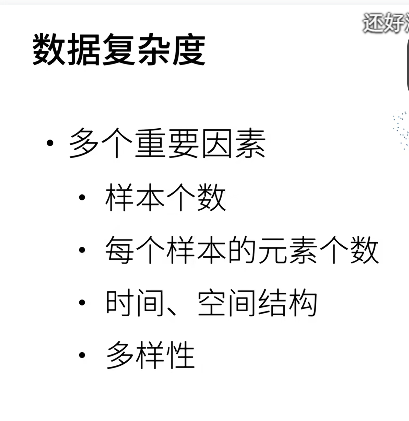

## 代码实现

In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

生成数据集

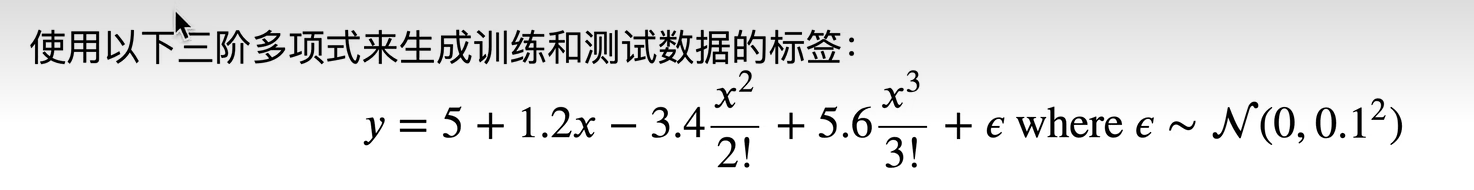

In [2]:
max_degree = 20 # 多项式的最⼤阶数
n_train, n_test = 100, 100 # 训练和测试数据集⼤⼩
true_w = np.zeros(max_degree) # 分配⼤量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1) # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [3]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
torch.float32) for x in [true_w, features, poly_features, labels]]
features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.7799],
         [-0.6589]]),
 tensor([[ 1.0000e+00, -7.7987e-01,  3.0410e-01, -7.9054e-02,  1.5413e-02,
          -2.4040e-03,  3.1247e-04, -3.4813e-05,  3.3937e-06, -2.9407e-07,
           2.2934e-08, -1.6260e-09,  1.0567e-10, -6.3392e-12,  3.5313e-13,
          -1.8360e-14,  8.9489e-16, -4.1053e-17,  1.7787e-18, -7.3007e-20],
         [ 1.0000e+00, -6.5893e-01,  2.1709e-01, -4.7683e-02,  7.8550e-03,
          -1.0352e-03,  1.1369e-04, -1.0702e-05,  8.8144e-07, -6.4534e-08,
           4.2524e-09, -2.5473e-10,  1.3987e-11, -7.0898e-13,  3.3369e-14,
          -1.4659e-15,  6.0369e-17, -2.3399e-18,  8.5658e-20, -2.9707e-21]]),
 tensor([2.7486, 3.0989]))

训练和测试

In [4]:
def evaluate_loss(net, data_iter, loss): #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2) # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [ ]:
def train(train_features, test_features, train_labels, test_labels,num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',xlim=[1, num_epochs], ylim=[1e-3, 1e2],legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

: 

三阶多项式函数拟合(正常)

In [ ]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],labels[:n_train], labels[n_train:])

d:\Develop\Anaconda_envs\envs\dl\lib\site-packages\d2l\torch.py:3057: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())


In [ ]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],labels[:n_train], labels[n_train:])

⾼阶多项式函数拟合(过拟合)

In [ ]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],labels[:n_train], labels[n_train:], num_epochs=1500)